# `fig_study_area` — Okavango Delta Study Region

**Purpose:** Publication-quality study area figure.

**Panels:**
- **(a)** Main map — Africa locator inset + zoomed Okavango Delta with polygon boundary, river network, key GRDC gauge stations  
- **(b)** DSWE hydroperiod seasonal stack — monthly-mean inundated area by calendar month (Landsat 1987–, Sentinel-2 2019–)  
- **(c)** Ground-truth photo insets at key field sites

**Output:** `../figures/study_area/fig_study_area.{png,pdf}`

## 1 · Import Libraries and Configure Paths

In [12]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
from matplotlib.offsetbox import AnchoredOffsetbox, AuxTransformBox
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    warnings.warn("cartopy not found – falling back to plain matplotlib/contextily map")

try:
    import contextily as cx
    HAS_CONTEXTILY = True
except ImportError:
    HAS_CONTEXTILY = False

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT        = Path("..").resolve()           # project root
DATA        = ROOT / "data"
FIG_OUT     = ROOT / "figures" / "study_area"
FIG_OUT.mkdir(parents=True, exist_ok=True)

DELTA_SHP   = DATA / "regions" / "Delta_UCB_WGS84" / "Delta_UCB_WGS84.shp"
REGIONS_PKG = DATA / "regions" / "okavango_regions.gpkg"
HIGHLANDS   = DATA / "regions" / "okavango_highlands.geojson"
GRDC_META   = DATA / "grdc_metadata_compiled.csv"

LANDSAT_DSWE   = DATA / "monthly_landsat_dswe.csv"
SENTINEL_DSWE  = DATA / "monthly_sentinel2_dswe.csv"
ANNUAL_FLOOD   = DATA / "annual_flood_area_km2.csv"
MOHEMBO_DAILY  = DATA / "mohembo_1357100_Q_daily.csv"

# ── Ground-truth photo sites ──────────────────────────────────────────────────
# Edit photo_path for each site once images are available.
# Use None to render a placeholder tile instead.
PHOTO_SITES = {
    "Mohembo (inlet)":    {"lon": 21.803,  "lat": -18.281, "photo": None},
    "Seronga":            {"lon": 22.396,  "lat": -18.824, "photo": None},
    "Chief's Island":     {"lon": 23.118,  "lat": -19.410, "photo": None},
    "Maun (outlet)":      {"lon": 23.416,  "lat": -19.983, "photo": None},
}

# ── CRS constants ────────────────────────────────────────────────────────────
WGS84    = "EPSG:4326"
EA_CRS   = "EPSG:6933"   # WGS 84 / NSIDC EASE-Grid 2.0 Global (equal-area)

# ── Style ─────────────────────────────────────────────────────────────────────
DELTA_COLOR  = "#8c2d04"   # brick red
BBOX_COLOR   = "#fdae6b"   # warm orange
SITE_MARKER  = "^"
SITE_COLOR   = "gold"
SITE_EDGE    = "k"
DPI          = 150

print("Paths OK:", DELTA_SHP.exists(), LANDSAT_DSWE.exists(), SENTINEL_DSWE.exists())


Paths OK: True True True


## 2 · Load and Reproject the Delta Shapefile

In [13]:
# ── Delta polygon ──────────────────────────────────────────────────────────────
delta_gdf = gpd.read_file(DELTA_SHP).to_crs(WGS84)
delta_union = delta_gdf.unary_union
delta_centroid = delta_union.centroid

# Tight bounding box (lon_min, lat_min, lon_max, lat_max)
minx, miny, maxx, maxy = delta_union.bounds
# Add a small margin for the map extent
MARGIN = 0.4   # degrees
map_extent = [minx - MARGIN, maxx + MARGIN, miny - MARGIN, maxy + MARGIN]
# cartopy order: [west, east, south, north]

# Bounding boxes — match the three geometry types used in ET-comparison notebook:
#   delta_polygon  → the exact delta shapefile polygon
#   poly_bbox      → tight bounding box derived from the delta polygon outline
#   okavango_bbox  → manually-specified wider study-area bbox
poly_bbox     = (minx, miny, maxx, maxy)              # tight bbox of delta polygon
okavango_bbox = (21.7913, -21.18, 25.0, -18.2694)     # manual wider study-area bbox

# Equal-area projection for area stats
delta_ea = gpd.GeoDataFrame(geometry=[delta_union], crs=WGS84).to_crs(EA_CRS)
delta_area_km2 = float(delta_ea.geometry.area.sum()) / 1e6

print(f"Delta centroid : {delta_centroid.y:.3f}°N, {delta_centroid.x:.3f}°E")
print(f"Bounding box   : {minx:.3f}–{maxx:.3f}°E, {miny:.3f}–{maxy:.3f}°N")
print(f"poly_bbox      : {poly_bbox}")
print(f"okavango_bbox  : {okavango_bbox}")
print(f"Delta area     : {delta_area_km2:,.0f} km²")

# ── Optional region layers ──────────────────────────────────────────────────
regions_gdf = gpd.read_file(REGIONS_PKG).to_crs(WGS84) if REGIONS_PKG.exists() else None
highlands_gdf = gpd.read_file(HIGHLANDS).to_crs(WGS84) if HIGHLANDS.exists() else None

# ── GRDC station metadata ───────────────────────────────────────────────────
if GRDC_META.exists():
    grdc_meta = pd.read_csv(GRDC_META)
    # Keep stations likely within the Okavango basin: rough lon/lat filter
    grdc_ok = grdc_meta[
        (grdc_meta["lon"].between(20, 26)) &
        (grdc_meta["lat"].between(-22, -17))
    ].copy()
else:
    grdc_ok = pd.DataFrame(columns=["station_name", "lon", "lat"])
    print("No GRDC metadata found — station layer will be empty")

# Always plot Mohembo as the primary gauge
MOHEMBO = {"name": "Mohembo\n(1357100)", "lon": 21.803, "lat": -18.281}
print(f"\nFound {len(grdc_ok)} GRDC stations in the map extent")


Delta centroid : -19.347°N, 22.954°E
Bounding box   : 21.791–24.033°E, -20.186–-18.269°N
poly_bbox      : (21.79128644270243, -20.185785441436625, 24.033221169007163, -18.26936168824883)
okavango_bbox  : (21.7913, -21.18, 25.0, -18.2694)
Delta area     : 23,317 km²

Found 9 GRDC stations in the map extent


## 3 · Load DSWE Inundation Time Series

In [14]:
# ── Load CHIRPS monthly precipitation ─────────────────────────────────────────
CHIRPS_REGIONS = DATA / "chirps_monthly_by_regions.csv"
chirps = pd.read_csv(CHIRPS_REGIONS)

# Average across all Okavango regions → single monthly climatology (mm)
chirps_monthly = (
    chirps.groupby("month")["precip_mm"]
    .mean()
    .reindex(range(1, 13))
)

# ── Load Mohembo monthly discharge ────────────────────────────────────────────
MOHEMBO_MONTHLY = DATA / "mohembo_1357100_Q_monthly_mean.csv"
mohembo_q = pd.read_csv(MOHEMBO_MONTHLY, parse_dates=["month"])
mohembo_q["mo"] = mohembo_q["month"].dt.month

# Mean discharge by calendar month (m³/s)
mohembo_monthly = (
    mohembo_q.groupby("mo")["Q_m3s_monthly_mean"]
    .mean()
    .reindex(range(1, 13))
)

# ── Annual flood area (for reference) ─────────────────────────────────────────
annual = pd.read_csv(ANNUAL_FLOOD) if ANNUAL_FLOOD.exists() else None
if annual is not None:
    print("Annual flood CSV columns:", annual.columns.tolist())

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

print("Seasonal mean precipitation (CHIRPS, mm):")
print(chirps_monthly.round(1).to_string())
print(f"\nSeasonal mean Mohembo discharge (m³/s):")
print(mohembo_monthly.round(1).to_string())
print(f"\nCHIRPS:  {chirps['year'].min()}–{chirps['year'].max()}, n={len(chirps)}")
print(f"Mohembo: {mohembo_q['month'].dt.year.min()}–{mohembo_q['month'].dt.year.max()}, n={len(mohembo_q)}")

Annual flood CSV columns: ['Unnamed: 0', 'year', 'landsat_jas_mean_km2', 'landsat_max_km2', 'sentinel_jas_mean_km2', 'il_annual_km2']
Seasonal mean precipitation (CHIRPS, mm):
month
1     156.3
2     123.0
3     110.9
4      31.7
5       0.5
6       0.0
7       0.0
8       0.0
9       3.2
10     26.4
11     74.0
12    120.0

Seasonal mean Mohembo discharge (m³/s):
mo
1     242.6
2     335.7
3     421.2
4     506.6
5     435.8
6     291.4
7     214.8
8     175.4
9     149.3
10    123.8
11    122.1
12    162.7

CHIRPS:  1990–2025, n=3424
Mohembo: 1974–2024, n=591


## 4 · Build the Static Basemap (cartopy) with Overlays and Africa Locator Inset

/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_79905/1029145914.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.5)


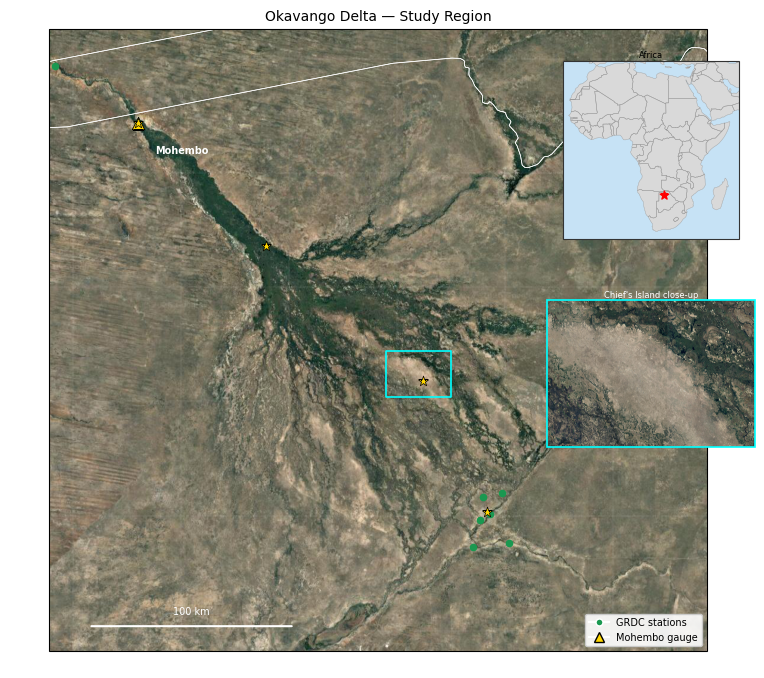

Main map built.


In [15]:
from shapely.geometry import box as _shp_box

# ── Close-up inset extent (Chief's Island / central delta channels) ───────────
INSET_EXTENT = [22.95, 23.25, -19.48, -19.28]   # [west, east, south, north]
INSET_ZOOM   = 14  # higher zoom for close-up detail


def _add_scalebar(ax, length_km: float = 100, x0=0.05, y0=0.03,
                  transform=None, fontsize=7, color="white"):
    """Draw a simple scale bar in axis-fraction coordinates."""
    if transform is None:
        transform = ax.transAxes
    # approximate degrees per km at the delta centroid latitude (~19°S)
    km_per_deg_lon = 111.32 * np.cos(np.radians(abs(delta_centroid.y)))
    deg_len = length_km / km_per_deg_lon
    ax_x0, ax_y0 = x0, y0
    ax.annotate(
        "",
        xy=(ax_x0 + 0.01 + deg_len / (map_extent[1] - map_extent[0]), ax_y0 + 0.01),
        xytext=(ax_x0 + 0.01, ax_y0 + 0.01),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="-", color=color, lw=1.5),
    )
    ax.text(
        ax_x0 + 0.01 + deg_len / (map_extent[1] - map_extent[0]) / 2,
        ax_y0 + 0.025,
        f"{length_km} km",
        ha="center", va="bottom",
        fontsize=fontsize, transform=ax.transAxes, color=color,
    )


if HAS_CARTOPY:
    import cartopy.io.img_tiles as cimgt
    SAT_TILES = cimgt.GoogleTiles(style="satellite")
    SAT_ZOOM = 9   # adjust for resolution vs. download speed

    PROJ = ccrs.PlateCarree()

    # ─────────────────────────────────────────────
    # Main map axis
    # ─────────────────────────────────────────────
    fig_map, ax_main = plt.subplots(
        figsize=(8, 7),
        subplot_kw={"projection": SAT_TILES.crs},
    )

    west, east, south, north = map_extent
    ax_main.set_extent([west, east, south, north], crs=PROJ)

    # Satellite imagery background
    ax_main.add_image(SAT_TILES, SAT_ZOOM)

    # Country borders (white for contrast on satellite)
    ax_main.add_feature(cfeature.NaturalEarthFeature(
        "cultural", "admin_0_countries", "10m",
        facecolor="none", edgecolor="white", linewidth=0.5))

    # GRDC stations
    if len(grdc_ok) > 0:
        ax_main.scatter(
            grdc_ok["lon"], grdc_ok["lat"],
            marker="o", c="#1a9850", s=20, zorder=6,
            transform=PROJ, label="GRDC stations",
        )

    # Mohembo gauge (primary upstream boundary)
    ax_main.scatter(
        MOHEMBO["lon"], MOHEMBO["lat"],
        marker=SITE_MARKER, c="gold", s=80, edgecolors="k", linewidths=0.6,
        zorder=7, transform=PROJ, label="Mohembo gauge",
    )
    ax_main.text(
        MOHEMBO["lon"] + 0.08, MOHEMBO["lat"] - 0.1,
        "Mohembo", fontsize=7, transform=PROJ,
        verticalalignment="top", color="white",
        fontweight="bold",
    )

    # Photo site markers
    for site_name, info in PHOTO_SITES.items():
        ax_main.scatter(
            info["lon"], info["lat"],
            marker="*", c=SITE_COLOR, s=60, edgecolors=SITE_EDGE, linewidths=0.5,
            zorder=8, transform=PROJ,
        )

    # Indicator rectangle for close-up inset
    iw, ie, is_, in_ = INSET_EXTENT
    ax_main.add_geometries(
        [_shp_box(iw, is_, ie, in_)], crs=PROJ,
        facecolor="none", edgecolor="cyan", linewidth=1.2, linestyle="-", zorder=9)

    # Gridlines
    gl = ax_main.gridlines(
        draw_labels=True, linewidth=0.3, color="white", alpha=0.5, linestyle=":",
        x_inline=False, y_inline=False,
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 7, "color": "white"}
    gl.ylabel_style = {"size": 7, "color": "white"}

    # Scale bar
    _add_scalebar(ax_main, length_km=100, fontsize=7, color="white")

    # Legend
    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#1a9850",
                   markersize=5, label="GRDC stations"),
        plt.Line2D([0], [0], marker=SITE_MARKER, color="w", markerfacecolor="gold",
                   markeredgecolor="k", markersize=7, label="Mohembo gauge"),
    ]
    ax_main.legend(handles=legend_handles, loc="lower right", fontsize=7,
                   framealpha=0.9)

    ax_main.set_title("Okavango Delta — Study Region", fontsize=10, pad=6)

    # ─────────────────────────────────────────────────────
    # Africa locator inset (top-left)
    # ─────────────────────────────────────────────────────
    ax_africa = fig_map.add_axes([0.74, 0.62, 0.22, 0.30],
                                  projection=PROJ)
    ax_africa.set_extent([-20, 55, -38, 38], crs=PROJ)
    ax_africa.add_feature(cfeature.NaturalEarthFeature(
        "physical", "land", "110m",
        facecolor="#d9d9d9", edgecolor="none"))
    ax_africa.add_feature(cfeature.NaturalEarthFeature(
        "physical", "ocean", "110m",
        facecolor="#c6e2f5", edgecolor="none"))
    ax_africa.add_feature(cfeature.NaturalEarthFeature(
        "cultural", "admin_0_countries", "110m",
        facecolor="none", edgecolor="#999", linewidth=0.3))
    ax_africa.scatter(
        delta_centroid.x, delta_centroid.y,
        marker="*", c="red", s=40, zorder=5, transform=PROJ,
    )
    ax_africa.set_title("Africa", fontsize=6, pad=2)
    for spine in ax_africa.spines.values():
        spine.set_edgecolor("#333")
        spine.set_linewidth(0.8)

    # ─────────────────────────────────────────────────────
    # Close-up satellite inset (bottom-right)
    # ─────────────────────────────────────────────────────
    ax_closeup = fig_map.add_axes([0.72, 0.28, 0.26, 0.34],
                                   projection=SAT_TILES.crs)
    ax_closeup.set_extent(INSET_EXTENT, crs=PROJ)
    ax_closeup.add_image(SAT_TILES, INSET_ZOOM)
    ax_closeup.set_title("Chief's Island close-up", fontsize=6, pad=2,
                          color="white")
    for spine in ax_closeup.spines.values():
        spine.set_edgecolor("cyan")
        spine.set_linewidth(1.2)

    plt.tight_layout(pad=1.5)
    plt.show()
    print("Main map built.")

else:
    # ── Fallback: geopandas + contextily ──────────────────────────────────────────
    fig_map, ax_main = plt.subplots(figsize=(8, 7))
    delta_gdf.plot(ax=ax_main, facecolor=DELTA_COLOR + "33",
                   edgecolor=DELTA_COLOR, linewidth=1.5)
    if HAS_CONTEXTILY:
        delta_gdf_web = delta_gdf.to_crs("EPSG:3857")
        fig2, ax2 = plt.subplots(figsize=(8, 7))
        delta_gdf_web.plot(ax=ax2, facecolor=DELTA_COLOR + "33",
                           edgecolor=DELTA_COLOR, linewidth=1.5)
        cx.add_basemap(ax2, source=cx.providers.Esri.WorldImagery, zoom=7)
        ax2.set_axis_off()
        ax2.set_title("Okavango Delta — Study Region (contextily)", fontsize=10)
        plt.tight_layout()
        plt.show()
        ax_main = ax2
    else:
        ax_main.set_xlim(minx - MARGIN, maxx + MARGIN)
        ax_main.set_ylim(miny - MARGIN, maxy + MARGIN)

## 5 · DSWE Hydroperiod Seasonal Stack (Inset Panel)

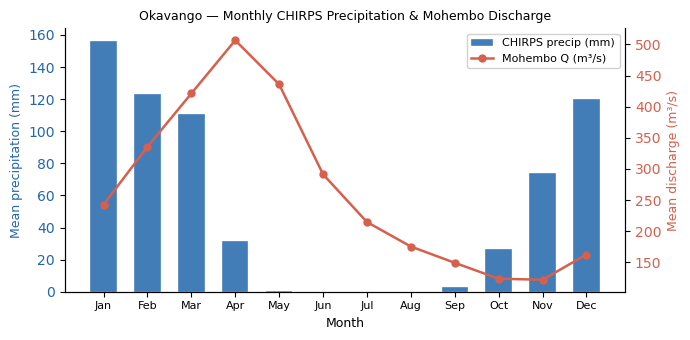

Hydroperiod panel saved.


In [16]:
# ── Colour palette ─────────────────────────────────────────────────────────────
COLOR_PRECIP = "#2166ac"   # blue  — CHIRPS precipitation
COLOR_Q      = "#d6604d"   # salmon-red — Mohembo discharge

# ── Dual-axis chart: CHIRPS precip bars + Mohembo discharge line ──────────────
fig_hydro, ax_precip = plt.subplots(figsize=(7, 3.5))

x = np.arange(1, 13)

# Left axis — CHIRPS precipitation (bars)
ax_precip.bar(x, chirps_monthly.values, width=0.6,
              color=COLOR_PRECIP, alpha=0.85, label="CHIRPS precip (mm)",
              edgecolor="white", linewidth=0.3)
ax_precip.set_ylabel("Mean precipitation (mm)", fontsize=9, color=COLOR_PRECIP)
ax_precip.tick_params(axis="y", labelcolor=COLOR_PRECIP)

# Right axis — Mohembo discharge (line with markers)
ax_q = ax_precip.twinx()
ax_q.plot(x, mohembo_monthly.values,
          color=COLOR_Q, marker="o", markersize=5, linewidth=1.8,
          label="Mohembo Q (m³/s)")
ax_q.set_ylabel("Mean discharge (m³/s)", fontsize=9, color=COLOR_Q)
ax_q.tick_params(axis="y", labelcolor=COLOR_Q)

ax_precip.set_xticks(x)
ax_precip.set_xticklabels(MONTH_LABELS, fontsize=8)
ax_precip.set_xlabel("Month", fontsize=9)
ax_precip.set_title("Okavango — Monthly CHIRPS Precipitation & Mohembo Discharge", fontsize=9)

# Combined legend
h1, l1 = ax_precip.get_legend_handles_labels()
h2, l2 = ax_q.get_legend_handles_labels()
ax_precip.legend(h1 + h2, l1 + l2, fontsize=8, framealpha=0.9, loc="upper right")

ax_precip.spines["top"].set_visible(False)
ax_q.spines["top"].set_visible(False)

fig_hydro.tight_layout()
fig_hydro.savefig(FIG_OUT / "fig_study_area_hydroperiod.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Hydroperiod panel saved.")

## 6 · Ground-Truth Photo Insets at Key Locations

/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_79905/3842064911.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_photos.tight_layout()


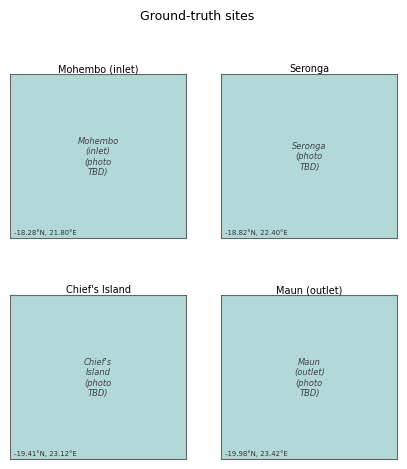

Photo panel saved.


In [17]:
def _placeholder_photo(ax, label: str, color: str = "#b2d8d8") -> None:
    """Draw a labelled placeholder tile when no photo is available."""
    ax.set_facecolor(color)
    ax.text(
        0.5, 0.5, label.replace(" ", "\n"),
        ha="center", va="center", transform=ax.transAxes,
        fontsize=6, style="italic", color="#444",
        wrap=True,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("#666")
        spine.set_linewidth(0.8)


def _load_photo(path: Path, ax) -> None:
    """Display an image file in an Axes."""
    img = mpimg.imread(str(path))
    ax.imshow(img, aspect="auto")
    ax.set_xticks([])
    ax.set_yticks([])


# ── 2×2 Photo grid ────────────────────────────────────────────────────────────
SITES = list(PHOTO_SITES.items())
n_photos = len(SITES)   # 4

fig_photos, axes_ph = plt.subplots(
    2, 2, figsize=(5, 5),
    gridspec_kw={"hspace": 0.35, "wspace": 0.2},
)
fig_photos.suptitle("Ground-truth sites", fontsize=9, y=1.01)

for ax_ph, (site_name, info) in zip(axes_ph.ravel(), SITES):
    photo_path = info.get("photo")
    if photo_path is not None and Path(photo_path).exists():
        _load_photo(Path(photo_path), ax_ph)
    else:
        _placeholder_photo(ax_ph, site_name + "\n(photo TBD)")
    ax_ph.set_title(site_name, fontsize=7, pad=2)
    ax_ph.text(
        0.02, 0.02,
        f"{info['lat']:.2f}°N, {info['lon']:.2f}°E",
        transform=ax_ph.transAxes, fontsize=5, color="#333",
        va="bottom",
    )

fig_photos.tight_layout()
fig_photos.savefig(FIG_OUT / "fig_study_area_photos.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Photo panel saved.")


## 7 · Compose and Export the Full `fig_study_area` Figure

Assemble all panels into a single GridSpec figure:

```
┌───────────────────┬────────────────────┐
│                   │  (b) Hydroperiod   │
│   (a) Main map    │  seasonal stack    │
│                   ├────────────────────┤
│                   │  (c)  Photos 2×2   │
└───────────────────┴────────────────────┘
```

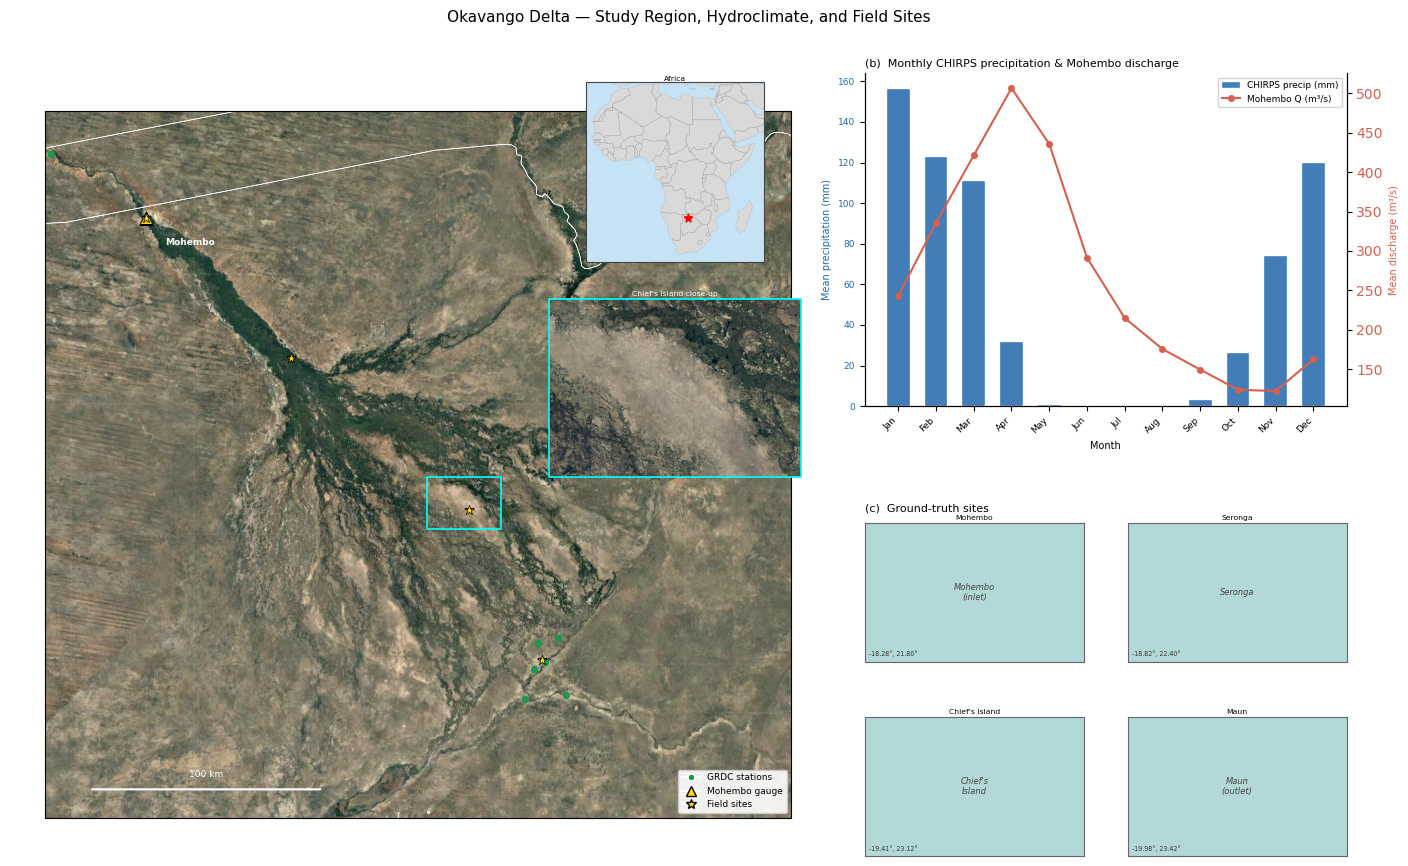

Saved → /Users/octaviacrompton/Projects/dswe-inman-lyons/figures/study_area/fig_study_area.png


In [18]:
from shapely.geometry import box as _shp_box

FIG_W, FIG_H = 14, 9   # inches (landscape)

if HAS_CARTOPY:
    import cartopy.io.img_tiles as cimgt
    SAT_TILES_C = cimgt.GoogleTiles(style="satellite")
    SAT_ZOOM_C  = 9

    # ── GridSpec layout ──────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(FIG_W, FIG_H), constrained_layout=False)

    gs = GridSpec(
        nrows=2, ncols=2,
        figure=fig,
        width_ratios=[1.55, 1],
        height_ratios=[1, 1],
        left=0.04, right=0.97,
        bottom=0.06, top=0.93,
        hspace=0.35, wspace=0.12,
    )

    # ── (a) Main map — spans both rows on the left ────────────────────────────
    ax_a = fig.add_subplot(gs[:, 0], projection=SAT_TILES_C.crs)
    ax_a.set_extent([west, east, south, north], crs=ccrs.PlateCarree())

    # Satellite imagery background
    ax_a.add_image(SAT_TILES_C, SAT_ZOOM_C)

    # Country borders (white for contrast on satellite)
    ax_a.add_feature(cfeature.NaturalEarthFeature(
        "cultural", "admin_0_countries", "10m",
        facecolor="none", edgecolor="white", linewidth=0.5))

    # GRDC stations
    if len(grdc_ok) > 0:
        ax_a.scatter(grdc_ok["lon"], grdc_ok["lat"],
                     marker="o", c="#1a9850", s=18, zorder=6,
                     transform=ccrs.PlateCarree(), label="GRDC stations")

    # Mohembo gauge
    ax_a.scatter(MOHEMBO["lon"], MOHEMBO["lat"],
                 marker=SITE_MARKER, c="gold", s=90, edgecolors="k", linewidths=0.7,
                 zorder=7, transform=ccrs.PlateCarree(), label="Mohembo gauge")
    ax_a.text(MOHEMBO["lon"] + 0.08, MOHEMBO["lat"] - 0.08, "Mohembo",
              fontsize=6.5, transform=ccrs.PlateCarree(), va="top", color="white",
              fontweight="bold")

    # Photo site markers
    for site_name, info in PHOTO_SITES.items():
        ax_a.scatter(info["lon"], info["lat"],
                     marker="*", c=SITE_COLOR, s=55, edgecolors=SITE_EDGE, linewidths=0.5,
                     zorder=8, transform=ccrs.PlateCarree())

    # Indicator rectangle for close-up inset
    iw, ie, is_, in_ = INSET_EXTENT
    ax_a.add_geometries(
        [_shp_box(iw, is_, ie, in_)], crs=ccrs.PlateCarree(),
        facecolor="none", edgecolor="cyan", linewidth=1.2, linestyle="-", zorder=9)

    # Gridlines
    gl_a = ax_a.gridlines(draw_labels=True, linewidth=0.3, color="white",
                           alpha=0.5, linestyle=":", x_inline=False, y_inline=False)
    gl_a.top_labels = False
    gl_a.right_labels = False
    gl_a.xlabel_style = {"size": 6, "color": "white"}
    gl_a.ylabel_style = {"size": 6, "color": "white"}

    _add_scalebar(ax_a, length_km=100, fontsize=6.5, color="white")

    _handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#1a9850",
                   markersize=5, label="GRDC stations"),
        plt.Line2D([0], [0], marker=SITE_MARKER, color="w", markerfacecolor="gold",
                   markeredgecolor="k", markersize=7, label="Mohembo gauge"),
        plt.Line2D([0], [0], marker="*", color="w", markerfacecolor=SITE_COLOR,
                   markeredgecolor="k", markersize=7, label="Field sites"),
    ]
    ax_a.legend(handles=_handles, loc="lower right", fontsize=6.5, framealpha=0.9)
    ax_a.set_title("(a)  Study region", fontsize=9, pad=5, loc="left", color="white")

    # Africa locator inset — upper right of panel (a)
    ax_africa_inset = fig.add_axes([0.42, 0.72, 0.14, 0.20],
                                    projection=ccrs.PlateCarree())
    ax_africa_inset.set_extent([-20, 55, -38, 38], crs=ccrs.PlateCarree())
    ax_africa_inset.add_feature(cfeature.NaturalEarthFeature(
        "physical", "land", "110m", facecolor="#d9d9d9", edgecolor="none"))
    ax_africa_inset.add_feature(cfeature.NaturalEarthFeature(
        "physical", "ocean", "110m", facecolor="#c6e2f5", edgecolor="none"))
    ax_africa_inset.add_feature(cfeature.NaturalEarthFeature(
        "cultural", "admin_0_countries", "110m",
        facecolor="none", edgecolor="#aaa", linewidth=0.25))
    ax_africa_inset.scatter(delta_centroid.x, delta_centroid.y,
                             marker="*", c="red", s=40, zorder=5,
                             transform=ccrs.PlateCarree())
    ax_africa_inset.set_title("Africa", fontsize=5.5, pad=1)
    for sp in ax_africa_inset.spines.values():
        sp.set_edgecolor("#444")
        sp.set_linewidth(0.8)

    # Close-up satellite inset — below Africa inset on panel (a)
    ax_closeup_c = fig.add_axes([0.40, 0.46, 0.18, 0.24],
                                 projection=SAT_TILES_C.crs)
    ax_closeup_c.set_extent(INSET_EXTENT, crs=ccrs.PlateCarree())
    ax_closeup_c.add_image(SAT_TILES_C, INSET_ZOOM)
    ax_closeup_c.set_title("Chief's Island close-up", fontsize=5.5, pad=2,
                            color="white")
    for sp in ax_closeup_c.spines.values():
        sp.set_edgecolor("cyan")
        sp.set_linewidth(1.2)

    # ── (b) CHIRPS precip + Mohembo discharge (top-right) ─────────────────────
    ax_b = fig.add_subplot(gs[0, 1])
    x = np.arange(1, 13)

    # Left axis — CHIRPS precipitation (bars)
    ax_b.bar(x, chirps_monthly.values, width=0.6,
             color=COLOR_PRECIP, alpha=0.85, label="CHIRPS precip (mm)",
             edgecolor="white", linewidth=0.3)
    ax_b.set_ylabel("Mean precipitation (mm)", fontsize=7, color=COLOR_PRECIP)
    ax_b.tick_params(axis="y", labelcolor=COLOR_PRECIP)

    # Right axis — Mohembo discharge (line with markers)
    ax_b_q = ax_b.twinx()
    ax_b_q.plot(x, mohembo_monthly.values,
                color=COLOR_Q, marker="o", markersize=4, linewidth=1.5,
                label="Mohembo Q (m³/s)")
    ax_b_q.set_ylabel("Mean discharge (m³/s)", fontsize=7, color=COLOR_Q)
    ax_b_q.tick_params(axis="y", labelcolor=COLOR_Q)

    ax_b.set_xticks(x)
    ax_b.set_xticklabels(MONTH_LABELS, fontsize=6.5, rotation=45, ha="right")
    ax_b.set_xlabel("Month", fontsize=7)

    # Combined legend
    h1, l1 = ax_b.get_legend_handles_labels()
    h2, l2 = ax_b_q.get_legend_handles_labels()
    ax_b.legend(h1 + h2, l1 + l2, fontsize=6.5, framealpha=0.9, loc="upper right")

    ax_b.spines["top"].set_visible(False)
    ax_b_q.spines["top"].set_visible(False)
    ax_b.tick_params(axis="both", labelsize=6.5)
    ax_b.set_title("(b)  Monthly CHIRPS precipitation & Mohembo discharge",
                    fontsize=8, pad=4, loc="left")

    # ── (c) Photo insets 2×2 (bottom-right) ───────────────────────────────────
    gs_inner = gs[1, 1].subgridspec(2, 2, hspace=0.4, wspace=0.2)
    photo_axes = [fig.add_subplot(gs_inner[r, c]) for r in range(2) for c in range(2)]

    for ax_ph, (site_name, info) in zip(photo_axes, SITES):
        photo_path = info.get("photo")
        if photo_path is not None and Path(photo_path).exists():
            _load_photo(Path(photo_path), ax_ph)
        else:
            _placeholder_photo(ax_ph, site_name)
        ax_ph.set_title(site_name.split(" (")[0], fontsize=5.5, pad=2)
        ax_ph.text(0.02, 0.03, f"{info['lat']:.2f}°, {info['lon']:.2f}°",
                   transform=ax_ph.transAxes, fontsize=4.5, color="#333", va="bottom")

    # Panel label placed above the photo grid using fig.text
    grid_bbox = gs[1, 1].get_position(fig)
    fig.text(grid_bbox.x0, grid_bbox.y1 + 0.01, "(c)  Ground-truth sites",
             fontsize=8, va="bottom", ha="left")

    # ── Overall title ──────────────────────────────────────────────────────────
    fig.suptitle(
        "Okavango Delta — Study Region, Hydroclimate, and Field Sites",
        fontsize=11, y=1,
    )

    fig.savefig(FIG_OUT / "fig_study_area.png",  dpi=300, bbox_inches="tight")
    fig.savefig(FIG_OUT / "fig_study_area.pdf",  bbox_inches="tight")
    plt.show()
    print(f"Saved → {(FIG_OUT / 'fig_study_area.png').resolve()}")

else:
    print("cartopy not available — assemble panels manually from the individual files saved above.")
    print(f"  Hydroperiod: {FIG_OUT / 'fig_study_area_hydroperiod.png'}")
    print(f"  Photos:      {FIG_OUT / 'fig_study_area_photos.png'}")

## 8 · Update Figure Registry

In [19]:
import datetime

REGISTRY = ROOT / "figures" / "registry.txt"

entry = (
    f"fig_study_area | "
    f"figures/study_area/fig_study_area.png | "
    f"figures/study_area/fig_study_area.pdf | "
    f"generated {datetime.date.today().isoformat()} | "
    f"notebook: notebooks/fig_study_area.ipynb\n"
)

existing = REGISTRY.read_text() if REGISTRY.exists() else ""

# Overwrite/update the entry for this figure
lines = [ln for ln in existing.splitlines(keepends=True)
         if not ln.startswith("fig_study_area")]
lines.append(entry)
REGISTRY.write_text("".join(lines))

print("Registry updated:")
print(entry.strip())


Registry updated:
fig_study_area | figures/study_area/fig_study_area.png | figures/study_area/fig_study_area.pdf | generated 2026-03-19 | notebook: notebooks/fig_study_area.ipynb


---
## Notes and Customisation

### Adding real ground-truth photos
Edit `PHOTO_SITES` in cell 1 to give each site a `"photo"` path, e.g.:
```python
PHOTO_SITES = {
    "Mohembo (inlet)": {"lon": 21.803, "lat": -18.281,
                        "photo": "../assets/photos/mohembo_360.jpg"},
    ...
}
```
Photos can be standard JPEG/PNG; 360° equirectangular images are treated the same way — the cell just calls `mpimg.imread`.

### Adding a satellite basemap tile
If `contextily` is installed, uncomment the `cx.add_basemap(...)` block inside the cartopy `else` branch, or merge it into the cartopy path by converting the delta GeoDataFrame to EPSG:3857 and using `ax.imshow` with a WMS URL.

### Adjusting the map extent / zoom
Change `MARGIN` in cell 2 or edit `map_extent` directly.

### Figure DPI and dimensions
`DPI = 300` and `FIG_W, FIG_H = 14, 9` are set in cell 1 and cell 7 respectively.

### EE / DSWE raster composites
The current seasonal inset uses the pre-computed monthly CSV (`monthly_landsat_dswe.csv`).  
To replace it with actual spatially-resolved EE raster composites:
1. Run Earth Engine to export seasonal mean DSWE images.
2. Load them as GeoTIFFs via `rioxarray` or `rasterio` and replace the bar chart in panel (b) with four `ax.imshow` calls arranged in a 1×4 grid.

Last updated: 2026